# El Salvador Synthetic Patient Explorer — the OMOP view

Welcome. This is a **guided, runnable tour** of a synthetic Salvadoran patient
population. It's meant to be *read like a short report*: press **Run all**, then
scroll down — each section explains, in plain terms, what you're looking at.

The patients here were generated by computer to resemble a real Salvadoran
population, then organized into **OMOP** — an international standard for health data.
Putting records into this common shape is what lets researchers anywhere analyze them
the same way, regardless of which country or hospital they came from. (It's the format
used by the worldwide [OHDSI](https://www.ohdsi.org/) research community.)

> ⚠️ **These are not real people, and nothing here is a finding about El Salvador.**
> Every record is synthetic — invented data used to build and test the tools safely,
> with zero real patient information.

**New to Colab?** You're in an interactive notebook. The grey cells are code that runs
automatically; the white text (like this) explains it. If you opened this from a share
link, choose **Runtime ▸ Change runtime type ▸ R**, then **Runtime ▸ Run all** — and
just read down the page.

## 1 · Getting set up

This first step loads a few free software tools the notebook needs to open the data
and draw its charts. You don't have to do anything — just let it run (a few seconds on
Colab). *For the curious: this is R loading `duckdb` to read the data and `ggplot2` to
plot it.*

In [1]:
# --- packages -------------------------------------------------------------
pkgs <- c("DBI", "duckdb", "dplyr", "tidyr", "ggplot2")
new  <- pkgs[!vapply(pkgs, requireNamespace, logical(1), quietly = TRUE)]
if (length(new)) install.packages(new, repos = "https://cloud.r-project.org")
suppressPackageStartupMessages({
  library(DBI); library(duckdb); library(dplyr); library(tidyr); library(ggplot2)
})
theme_set(theme_minimal(base_size = 13))
cat("ready — duckdb R", as.character(packageVersion("duckdb")), "\n")

ready — duckdb R 1.5.4.2 


## 2 · Loading the data

The whole population lives in a single small file — a lightweight database that travels
as easily as a spreadsheet, so there's nothing to install or set up.

On Colab the file downloads automatically the first time you run it. If you're instead
running this on your own computer inside the project folder, the notebook simply finds
it next to itself. Either way, the next cell just works.

In [2]:
# ── DATA SOURCE ───────────────────────────────────────────────────────────
# Pre-wired to this repo's raw GitHub file so Colab works out of the box.
# Running locally in a clone? It auto-finds OMOP/sv_sample100.duckdb in the repo first.
DATA_URL <- "https://github.com/rcurrie/sov-hlth-prot/raw/main/OMOP/sv_sample100.duckdb"

# --- locate or fetch the OMOP database ------------------------------------
db_path  <- Sys.getenv("SV_OMOP_DB",  "sv_sample100.duckdb")
data_url <- if (nzchar(Sys.getenv("SV_OMOP_URL"))) Sys.getenv("SV_OMOP_URL") else DATA_URL

# common local locations when running inside the repo
# (prefers the compact 100-person demo subset if present, else the full corpus)
if (!file.exists(db_path)) {
  for (p in c("OMOP/sv_sample100.duckdb", "../OMOP/sv_sample100.duckdb",
              "sv_sample100.duckdb", "notebooks/sv_sample100.duckdb",
              "data/omop/sv.duckdb", "../data/omop/sv.duckdb")) {
    if (file.exists(p)) { db_path <- p; break }
  }
}
if (!file.exists(db_path) && nzchar(data_url)) {
  message("downloading corpus from ", data_url)
  download.file(data_url, (db_path <- "sv.duckdb"), mode = "wb")
}
stopifnot("sv.duckdb not found — set SV_OMOP_URL or place the file next to the notebook" =
          file.exists(db_path))
cat("using OMOP database:", normalizePath(db_path), "\n")

using OMOP database: /Users/rcurrie/doctor-causal-sv/estimator-stack/notebooks/sv_sample100.duckdb 


## 3 · Opening the data

Now we open a connection to the database so we can ask it questions.

One quiet but important idea lives here: because the data is in the standard OMOP shape,
the *exact same* analysis code runs against a tiny demo file like this one **or** against
a national-scale hospital database — the questions below wouldn't change at all. That
portability is the whole reason for adopting a shared standard. *(In a full project you'd
connect with OHDSI's `DatabaseConnector`; we use a lighter driver here so Colab starts in
seconds.)*

In [3]:
# --- connect (read-only) --------------------------------------------------
con <- dbConnect(duckdb::duckdb(), dbdir = db_path, read_only = TRUE)

# tiny helper: run OMOP SQL, get a data.frame back
q <- function(sql) dbGetQuery(con, sql)

# what tables did the ETL populate?  (cdm_* / *_occurrence / measurement / ...)
q("SELECT table_name FROM information_schema.tables
   WHERE table_schema = 'main' AND table_name NOT LIKE 'src_%'
   ORDER BY table_name")

table_name
<chr>
cdm_source
cohort
cohort_definition
concept
concept_relationship
condition_occurrence
death
drug_exposure
measurement


## 4 · A first look: where's this from, and how much is there?

Every OMOP dataset carries a small "provenance stamp" recording where it came from. We
read that, then count how many records sit in each part of the medical record —
patients, visits, diagnoses, medications, lab results. Think of it as checking the
source and size of the dataset before diving in.

In [4]:
# provenance
q("SELECT cdm_source_name, source_description, cdm_version FROM cdm_source")

cdm_source_name,source_description,cdm_version
<chr>,<chr>,<chr>
synthea-nemotron-sv-100,"El Salvador-calibrated Synthea corpus (synthea-nemotron, phase 1) — 100-person demo subset",5.4


In [5]:
# row counts across the core OMOP domains
core <- c("person","observation_period","visit_occurrence","condition_occurrence",
          "drug_exposure","measurement","death")
counts <- data.frame(
  table = core,
  rows  = vapply(core, function(t) as.integer(q(sprintf("SELECT COUNT(*) n FROM %s", t))$n), integer(1))
)
counts$rows <- format(counts$rows, big.mark = ",")
knitr::kable(counts, align = c("l","r"), caption = "Core OMOP CDM table sizes")



Table: Core OMOP CDM table sizes

|                     |table                |    rows|
|:--------------------|:--------------------|-------:|
|person               |person               |     100|
|observation_period   |observation_period   |     100|
|visit_occurrence     |visit_occurrence     |  28,981|
|condition_occurrence |condition_occurrence |  17,060|
|drug_exposure        |drug_exposure        |  23,908|
|measurement          |measurement          | 255,744|
|death                |death                |      20|

## 5 · Meet the patients

The heart of any health dataset is its list of patients — one row per person. Here we
pull up a sample so you can see how you'd reach an individual's record.

> This shared demo file is a **100-patient sample** drawn from a larger 566-patient
> population. It was chosen to keep everyone who has diabetes or kidney disease (so the
> story below stays intact) while staying small enough to email around. You can point
> the notebook at the full population at any time — every chart adjusts itself to
> whatever is loaded.

In [6]:
REFERENCE_YEAR <- 2026L   # corpus observation window ends mid-2026

roster <- q(sprintf(
 "SELECT person_id,
         gender_source_value                    AS sex,
         year_of_birth,
         %d - year_of_birth                      AS age,
         ethnicity_source_value                  AS ethnicity,
         person_source_value                     AS source_id
    FROM person
   ORDER BY person_id
   LIMIT 100", REFERENCE_YEAR))

cat("sampled", nrow(roster), "of",
    q("SELECT COUNT(*) n FROM person")$n, "patients\n\n")
head(roster, 10)

sampled 100 of 100 patients



,person_id,sex,year_of_birth,age,ethnicity,source_id
,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,1,F,2018,8,hispanic,0001b390-595e-84cb-466e-4cc8ba71577e
2,2,F,1970,56,hispanic,014ca8e3-3f80-6640-8865-14734c5ab9a3
3,3,F,2002,24,hispanic,016280d2-d2bb-d608-2b26-08eb58346bfd
4,4,F,2014,12,hispanic,0172e4ef-27fd-67bf-374b-9f1a7e59c5a7
5,5,F,1996,30,hispanic,01fb4517-2923-fa6f-0d41-fbd03d6fcfb8
6,6,F,2023,3,hispanic,025d81f4-a4c1-21a3-cad9-0cbd848de40d
7,7,M,1968,58,hispanic,0282d90b-526b-5488-a158-69f50023eb4e
8,8,M,2017,9,hispanic,028e6d89-26e5-9871-2b85-2fc2410c704a
9,9,F,2011,15,hispanic,03822e38-8c6c-0043-93fe-9ed5822979a4


## 6 · Who are they? A look at age and sex

Because these synthetic patients were modeled on El Salvador's 2024 census, the
population should skew **younger** than, say, a typical US dataset. The age-and-sex
"pyramid" below is a quick way to confirm the shape of the population looks right.

mean age: 54 years   |    female: 60 %


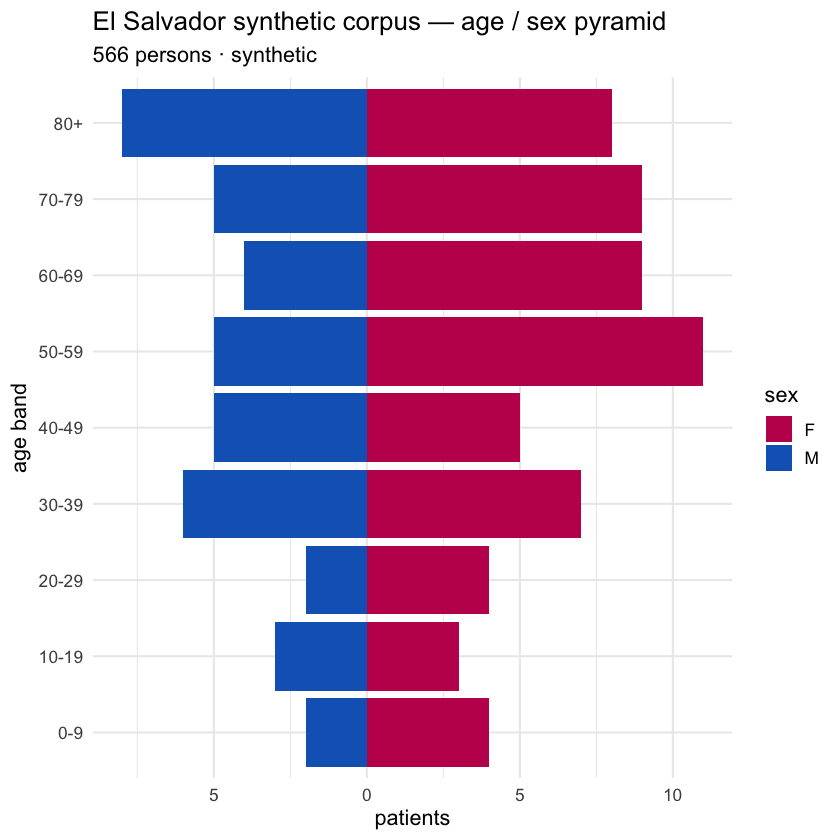

In [7]:
people <- q(sprintf(
  "SELECT person_id, gender_source_value AS sex, %d - year_of_birth AS age
     FROM person", REFERENCE_YEAR))

bands <- c(0,10,20,30,40,50,60,70,80,Inf)
pyr <- people %>%
  mutate(age = pmax(age, 0),
         band = cut(age, breaks = bands, right = FALSE,
                    labels = c("0-9","10-19","20-29","30-39","40-49",
                               "50-59","60-69","70-79","80+"))) %>%
  count(sex, band) %>%
  mutate(n_signed = ifelse(sex == "M", -n, n))

cat("mean age:", round(mean(people$age)), "years   |   ",
    "female:", round(100*mean(people$sex=="F")), "%\n")

ggplot(pyr, aes(x = band, y = n_signed, fill = sex)) +
  geom_col() + coord_flip() +
  scale_y_continuous(labels = function(x) abs(x)) +
  labs(title = "El Salvador synthetic corpus — age / sex pyramid",
       subtitle = "566 persons · synthetic", x = "age band", y = "patients") +
  scale_fill_manual(values = c(F = "#c2185b", M = "#1565c0"))

## 7 · What conditions show up — the El Salvador signal

Diagnoses in this data are recorded with **SNOMED** codes (a widely used international
medical vocabulary). The population was deliberately built to reflect two conditions
that weigh heavily on El Salvador — **chronic kidney disease of non-traditional causes**
(**CKDu**, or "Mesoamerican nephropathy") and **dengue** — alongside the usual chronic
diseases. Below we count how many distinct patients carry each condition of interest.

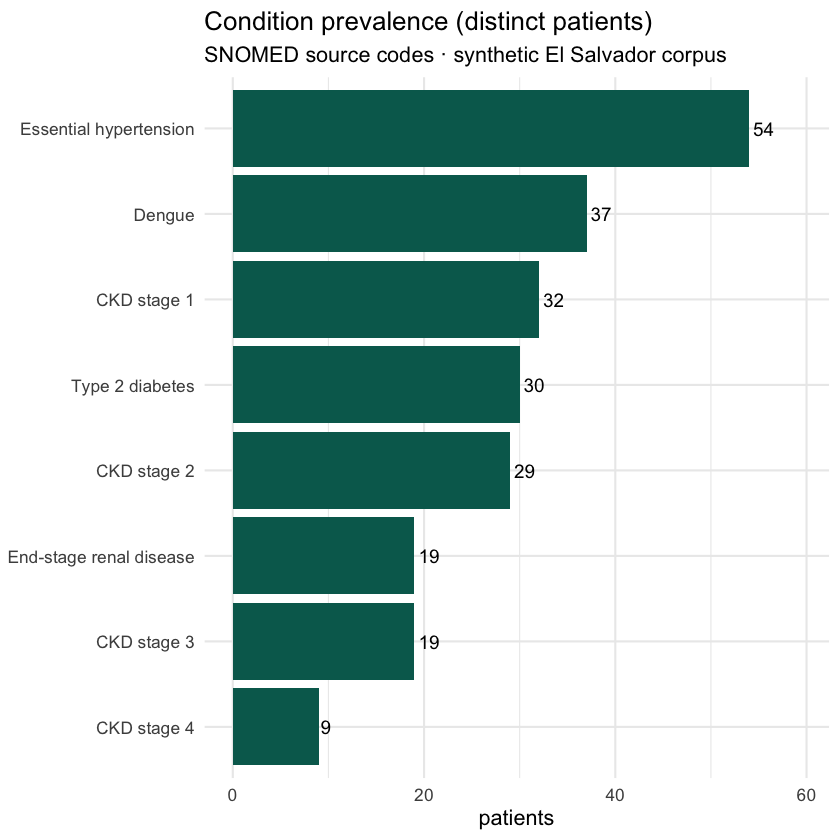

In [8]:
dx <- data.frame(
  code = c("44054006","59621000","431855005","431856006",
           "433144002","431857002","46177005","38362002"),
  label = c("Type 2 diabetes","Essential hypertension","CKD stage 1","CKD stage 2",
            "CKD stage 3","CKD stage 4","End-stage renal disease","Dengue"),
  stringsAsFactors = FALSE
)

codes_sql <- paste(sprintf("'%s'", dx$code), collapse = ",")
burden <- q(sprintf(
 "SELECT condition_source_value AS code, COUNT(DISTINCT person_id) AS patients
    FROM condition_occurrence
   WHERE condition_source_value IN (%s)
   GROUP BY 1", codes_sql)) %>%
  right_join(dx, by = "code") %>%
  mutate(patients = coalesce(patients, 0L)) %>%
  arrange(desc(patients))

ggplot(burden, aes(reorder(label, patients), patients)) +
  geom_col(fill = "#00695c") +
  geom_text(aes(label = patients), hjust = -0.2, size = 4) +
  coord_flip() +
  labs(title = "Condition prevalence (distinct patients)",
       subtitle = "SNOMED source codes · synthetic El Salvador corpus",
       x = NULL, y = "patients") +
  expand_limits(y = max(burden$patients) * 1.1)

## 8 · The kidney-disease thread

Kidney disease is El Salvador's signature health burden, so it's worth a closer look.
We show two familiar views: how patients are spread across the **stages of chronic
kidney disease** (mild through severe), and the distribution of **eGFR** — a routine
blood test of kidney function — with the usual clinical cut-offs drawn in. We also look
at how often diabetes and kidney disease occur **together** versus separately, since
that distinction (diabetic kidney disease vs. the CKDu pattern) carries real clinical
meaning.

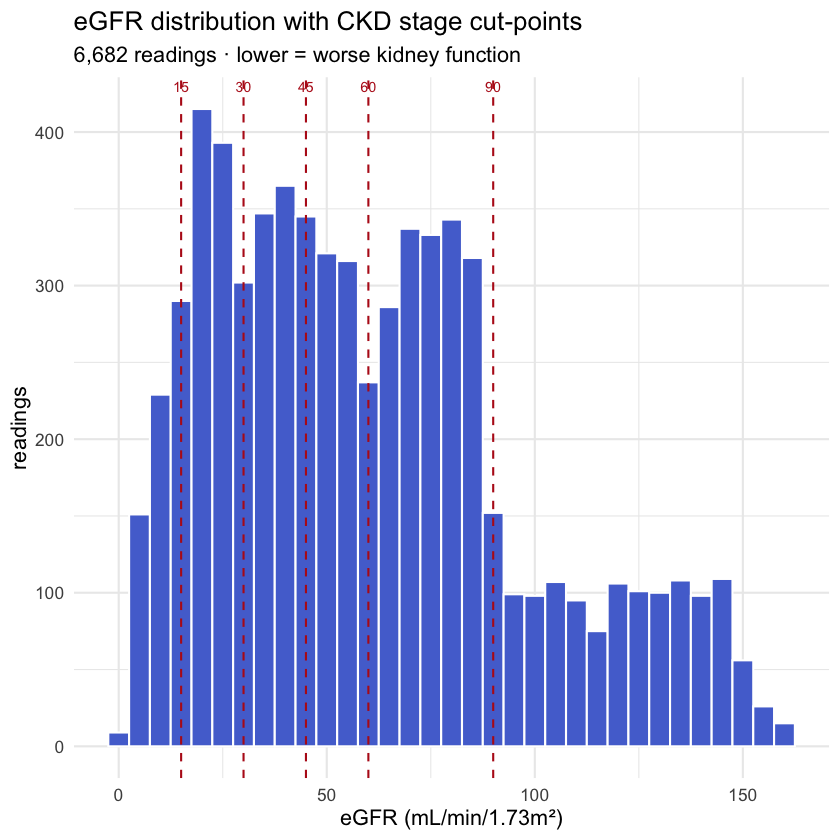

In [9]:
# eGFR readings (LOINC 33914-3), with CKD stage boundaries
egfr <- q("SELECT value_as_number AS egfr FROM measurement
           WHERE measurement_source_value = '33914-3'
             AND value_as_number IS NOT NULL")

cuts <- c(15, 30, 45, 60, 90)   # G-stage boundaries (mL/min/1.73m2)
ggplot(egfr, aes(egfr)) +
  geom_histogram(binwidth = 5, fill = "#5472d3", colour = "white") +
  geom_vline(xintercept = cuts, linetype = "dashed", colour = "#b71c1c") +
  annotate("text", x = cuts, y = Inf, vjust = 1.4, size = 3, colour = "#b71c1c",
           label = c("15","30","45","60","90")) +
  labs(title = "eGFR distribution with CKD stage cut-points",
       subtitle = sprintf("%s readings · lower = worse kidney function", format(nrow(egfr), big.mark=",")),
       x = "eGFR (mL/min/1.73m²)", y = "readings")

In [10]:
# diabetes <-> CKD overlap
ckd_codes <- "'431855005','431856006','433144002','431857002','46177005','709044004'"
ovl <- q(sprintf("
  WITH dm  AS (SELECT DISTINCT person_id FROM condition_occurrence WHERE condition_source_value='44054006'),
       ckd AS (SELECT DISTINCT person_id FROM condition_occurrence WHERE condition_source_value IN (%s))
  SELECT
    (SELECT COUNT(*) FROM dm)                                             AS diabetes,
    (SELECT COUNT(*) FROM ckd)                                            AS ckd_any,
    (SELECT COUNT(*) FROM dm  WHERE person_id IN (SELECT person_id FROM ckd)) AS both", ckd_codes))
knitr::kable(ovl, caption = "Patient counts — diabetes, CKD, and the overlap")



Table: Patient counts — diabetes, CKD, and the overlap

| diabetes| ckd_any| both|
|--------:|-------:|----:|
|       30|      50|    8|

## 9 · Zooming in on one patient

Big datasets can feel abstract, so let's follow a single person. We pick one patient who
has **both diabetes and kidney disease** and rebuild their story over time — their
diagnoses, some common long-term medications, and how their **HbA1c** (a measure of
blood-sugar control) and **eGFR** (kidney function) changed across the years. Every
large study is assembled from individual records exactly like this one.

In [11]:
# pick the first patient with T2DM AND CKD
pid <- q(sprintf("
  SELECT person_id FROM condition_occurrence WHERE condition_source_value='44054006'
  INTERSECT
  SELECT person_id FROM condition_occurrence WHERE condition_source_value IN (%s)
  ORDER BY 1 LIMIT 1", ckd_codes))$person_id[1]
cat("patient", pid, "\n")

# their conditions (first onset per code), labelled where we know the code
dxall <- setNames(dx$label, dx$code)
conds <- q(sprintf("SELECT condition_source_value AS code, MIN(condition_start_date) AS onset,
                           COUNT(*) AS records
                      FROM condition_occurrence WHERE person_id = %d
                     GROUP BY 1 ORDER BY onset", pid))
conds$label <- ifelse(conds$code %in% names(dxall), dxall[conds$code], paste0("SNOMED ", conds$code))
head(conds[, c("onset","label","records")], 12)

patient 21 


,onset,label,records
,<date>,<chr>,<dbl>
1,1966-11-20,SNOMED 314529007,158
2,1968-02-14,SNOMED 195662009,6
3,1969-07-13,SNOMED 444814009,6
4,1970-01-10,SNOMED 263102004,1
5,1970-01-10,SNOMED 125605004,1
6,1971-12-01,SNOMED 44465007,1
7,1971-12-01,SNOMED 384709000,1
8,1974-11-18,Dengue,2
9,1976-10-10,SNOMED 66383009,56


In [12]:
# common chronic-disease medications this patient received (labelled RxNorm subset)
rx <- c("860975"="Metformin ER", "106892"="Insulin",
        "314076"="Lisinopril (ACE-I)", "310798"="Hydrochlorothiazide")
meds <- q(sprintf("SELECT drug_source_value AS code, MIN(drug_exposure_start_date) AS started,
                          COUNT(*) AS fills
                     FROM drug_exposure WHERE person_id = %d
                       AND drug_source_value IN (%s)
                    GROUP BY 1", pid, paste(sprintf("'%s'", names(rx)), collapse=","))) %>%
  mutate(drug = rx[code]) %>% arrange(started)
knitr::kable(meds[, c("started","drug","fills")], caption = paste("Chronic-disease drugs — patient", pid))



Table: Chronic-disease drugs — patient 21

|started    |drug                | fills|
|:----------|:-------------------|-----:|
|2006-11-27 |Hydrochlorothiazide |   290|
|2006-11-27 |Lisinopril (ACE-I)  |   290|
|2009-03-23 |Metformin ER        |   286|
|2009-03-23 |Insulin             |   286|

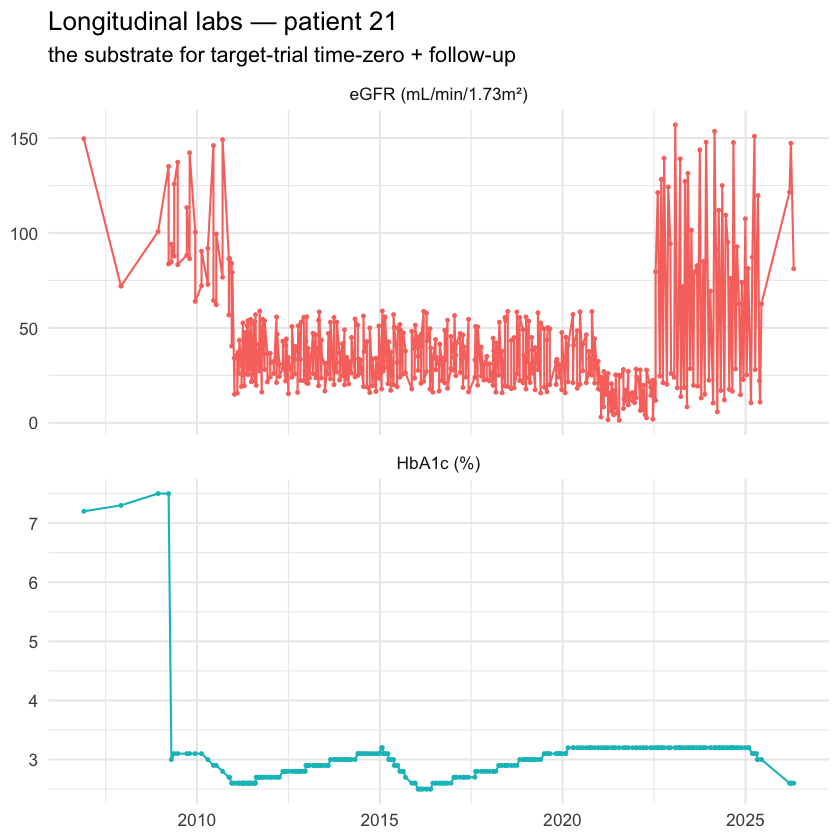

In [13]:
# HbA1c + eGFR trajectories for this patient
labs <- q(sprintf("
  SELECT measurement_date AS date, measurement_source_value AS code, value_as_number AS value
    FROM measurement
   WHERE person_id = %d AND measurement_source_value IN ('4548-4','33914-3')
     AND value_as_number IS NOT NULL
   ORDER BY date", pid)) %>%
  mutate(lab = recode(code, "4548-4" = "HbA1c (%)", "33914-3" = "eGFR (mL/min/1.73m²)"),
         date = as.Date(date))

ggplot(labs, aes(date, value, colour = lab)) +
  geom_line() + geom_point(size = 0.6) +
  facet_wrap(~lab, scales = "free_y", ncol = 1) +
  guides(colour = "none") +
  labs(title = paste("Longitudinal labs — patient", pid),
       subtitle = "the substrate for target-trial time-zero + follow-up",
       x = NULL, y = NULL)

## 10 · Where this goes next

What you just walked through — describing who is in the data and what they have — is the
standard *first* step in this kind of research. Two honest notes on what comes after:

1. **Translating the medical codes is the next real task.** Right now each diagnosis,
   drug, and lab still wears its original code. Before the most powerful analysis tools
   can be used, those codes have to be matched to OMOP's shared dictionary of *standard
   concepts* — a well-understood, but genuine, piece of work.

2. **From describing to comparing.** Once that's done, the natural next study is a
   careful head-to-head comparison of two treatments and how patients fare — for
   example, whether one diabetes medication protects the kidneys better than another.
   *(In OHDSI terms, a new-user, active-comparator study with propensity weighting — the
   design behind large published studies.)* This project already includes a worked
   example that checks the method against a **known** answer (`scripts/shp/study/diabetes/`),
   so we can trust the machinery before trusting it with real data. On this synthetic
   data the treatment groups are deliberately too small for a real comparison — that
   waits on richer data.

> **The point of this notebook:** give everyone on the team a one-click way to open the
> data, see the population, and trust the plumbing — *before* a single real patient
> record is ever involved.

In [14]:
dbDisconnect(con, shutdown = TRUE)
cat("disconnected — end of tour\n")

disconnected — end of tour
